# Mini-Project: Tandem Fur Box Multiplicity and the Saturation of Fur-Mediated Transcriptional Repression
**Intern:** 김규성  
**Date started:** 2026-07-28  


---
## Context

You have already worked with this dataset in Module 4:

- **Data:** Fur ChIP-exo binding sites from Seo et al. 2014 — *Nature Communications* 5:4910 (GEO series **GSE54901** for the raw signal; the discrete binding sites come from the paper's **Supplementary Data** table you downloaded in Module 4)
- **Organism:** *E. coli* K-12 MG1655
- **Files in `data/reference/`:** Fur binding-site table (iron-replete sites, with `ChIP-exo Start`/`End`, `S/N ratio`, `Significance`, `Distance to TSS`), `NC_000913.fasta`, `ec_annotation_20100903_DHK_cSRNA_with_ortho.gff`, and the `fur_sites_for_meme.fasta` you generated.

Module 4 asked one specific question: *find the FUR binding motif.* This project asks you to go further and answer a question of your own choosing about the FUR regulon.


---
## Schedule Overview

| Day | Target milestone |
|-----|------------------|
| W5 D1 | Literature review done; candidate questions drafted |
| W5 D2 | Biological question finalized and instructor-approved |
| W5 D3 | Analysis plan written; pipeline scaffold annotated |
| W5 D4–5 | Pipeline running; first results visible |
| W6 D1–3 | All steps done; figures generated |
| W6 D4–5 | Report written; notebook submitted |

Run `/log` at the end of **every day**.


---
## Part 1 — What Else Is Known About FUR?
**Target: W5 Day 1**

You already know the Seo et al. 2014 dataset. Before proposing a question, find out what other groups have studied about the FUR regulon in *E. coli* — you want to ask something that either extends, challenges, or fills a gap in the existing literature.

Use Claude to help search and summarize. Key questions to answer:
- What genes are in the known FUR regulon?
- What is already known about FUR binding site position relative to promoters/TSS?
- Are there known differences between iron-replete and iron-depleted conditions?
- What aspects of FUR binding have *not* been studied with ChIP-exo?


**Literature summary** — 4–6 sentences covering what is known and what gaps exist:


> **Answer**
>
> FUR Regulon에는 철 흡수와 관련된 enterobactin(entCEBA, ybdB, entD 등), ferrichrome/hydroxamate siderophore system(fhuA, fhuB, fhuC 등), Ferric citrate system(fecABCDE, fecIR) 등 철의 흡수와 저장 및 스트레스 대응 유전자들이 포함된다.
>
> FUR binding site와 promoter/TSS의 위치 관계가 알려져 있다 - Fur box: 19 bp의 palindromic 서열 "GATAATGATAATCATTATC"이 알려져 있으며, Baichoo & Helmann, 2002에서 실제 Fur은 7-1-7 bp의 inverted repeat 서열을 인식하는 것으로 알려져 있다.
>
> 철이 충분한 환경에서 Fur는 Fe2+가 결합한 holo 형태로 존재하여, dimer 및 polymer를 이루며 유전자의 RNAP-binding region 바로 위 또는 근처의 Fur box에 결합, RNAP 또는 시그마 인자가 접근하는 것을 물리적으로 차단한다. -> holo-Fur repression
>
> 철이 부족한 환경에서는 Fur가 DNA 친화성이 낮은 apo 형태로 존재하여 genome에서 이탈하게 된다. -> derepression, a.k.a. apo-Fur activation
>
> ChIP-exo로 아직 연구되지 않은 부분: (1) 현재 데이터는 mid-exponential 시기에 ChIP-exo를 함. exponential~stationary transition 시기에 같은 조건으로 ChIP-exo 연구된 바 없음. (2) iron replete vs chelator 첨가 후 단일 고정된 timepoint에서만 측정함. 철이 고갈됨에 따라 Fur가 binding site를 떠나는 역학은 연구되지 않음. (3) Fur oligomeric stoichiometry: ChIP-exo는 binding-footprint의 위치와 대략적인 signal strength만 제공하는 한계가 있어, 특정 tandem/polymerized site에 몇 개의 Fur dimer가 결합하는지, 또는 결합되는 Fur의 assembly의 순서는 알 수 없음. single-molecule imaging, AFM 등 orthogonal biophysical method가 필요. (4) Fur는 OxyR(산화 스트레스 반응), acid stress, biofilm regulator들과 cross-talk하는 것으로 알려져 있으나, 철 유무를 산화스트레스/pH 스트레스/삼투 스트레스와 동시에 변화시켜 condition-dependent co-occupancy shift를 mapping한 ChIP-exo 데이터셋은 없음 (5) single-cell heterogeneity: ChIP-exo는 population-averaged된 방법. Fur occupancy가 population 전체에서 균일한지, 혹은 biomdal/heterogenous한지는 ChIP-exo 만으로 알수 없음. (6) 동일 실험 프레임워크 내에서 RyhB/Hfq와의 direct co-mapping이 되어 있지 않음. RyhB-mediated된 regulon의 간접적인 arm은 유전학적으로, 그리고 RNA-seq을 통해 잘 규명되어 있음. 그러나 이것이 동일한 ChIP-exo binding map과 통합된 단일 연구로 직접 연결된 적이 없어, RyhB 자신의 타겟들은 Fur occupancy와 함께 co-profiling되지 않고, 별도의 sRNA-target 데이터셋으로부터 추론됨.
>
> (3)에서 착안하여, 본 프로젝트에서 두 가설을 검증한다. 여기서 'tandem Fur box'는 Seo et al. 2014의 `# of motifs` 컬럼이 나타내는 — 한 결합 부위 안에 완전한 Fur box가 여러 개(n=1–4) 존재하는 경우를 가리킨다. (`# of motifs`는 Seo et al. 2014가 자체 방법으로 계산해 제공한 값을 그대로 사용한 것이며, 각 motif가 genome 상에서 실제로 머리-꼬리로 연속 배치되어 있는지는 이 프로젝트에서 서열 수준으로 직접 검증하지 않았다 — "tandem"은 편의상 붙인 표현이다.) (가설 1) n이 클수록 결합 친화도가 높아져 ChIP-exo S/N ratio도 함께 증가할 것이다. (가설 2) 반면 전사 억제는 holo-Fur dimer 하나만으로도 RNAP/시그마 인자 결합 부위를 충분히 가릴 수 있는 steric-hindrance 기전이므로, n이 늘어도 발현 억제 정도(iron-replete vs iron-starve log2FC)는 어느 지점 이후 포화되어 occupancy 증가만큼 비례해 강해지지는 않을 것이다.

> **W5 D1 checkpoint:**
> - [ ] At least 2 papers read beyond Seo et al. 2014
>
> Escolar, L., Pérez-Martín, J., & de Lorenzo, V. (1998). Binding of the Fur (Ferric Uptake Regulator) repressor of Escherichia coli to arrays of the GATAAT sequence. Journal of Molecular Biology, 283(3), 537–547. https://doi.org/10.1006/jmbi.1998.2119
> 
> Chen, Z., Lewis, K. A., Shultzaberger, R. K., Lyakhov, I. G., Zheng, M., Doan, B., Storz, G., & Schneider, T. D. (2007). Discovery of Fur binding site clusters in Escherichia coli by information theory models. Nucleic Acids Research, 35(20), 6762–6777. https://doi.org/10.1093/nar/gkm631
>
> - [ ] Gap or open question identified
> - [ ] `/log` run


---
## What Makes a Good Biological Question?

Before writing your question, use this checklist:

| Criterion | Ask yourself |
|-----------|-------------|
| **Answerable with available data** | Can you answer it using the files already in `data/reference/`? |
| **Not already answered** | Did Seo et al. 2014 or the papers you just read already answer this? |
| **Has a plausible mechanism** | If you found a pattern, would there be a biological reason for it? |
| **Specific and testable** | Can you describe the analysis in 2–3 steps and know what result would count as a "yes" or "no"? |

> **What the binding-site table gives you:** each Fur site has a `ChIP-exo Start`/`End`, a **`S/N ratio`** and a **`Significance (p-value)`** (these are the *signal-strength* / *score* fields — the `Peak` column is just an ID label like `P1`), a `Binding Condition` (`R` iron-replete / `S` iron-depleted / `R/S` both), and a `Distance to TSS` for many sites. Design your question around columns that actually exist.

### Examples of tractable questions with the FUR dataset

- *Do FUR binding sites closer to a TSS have a higher S/N ratio than sites far from a TSS?*
- *Are FUR sites that bind in both conditions (`R/S`) stronger (higher S/N ratio) than condition-specific ones?*
- *Does the GC content of FUR binding site sequences correlate with the site's S/N ratio?*
- *Which functional categories (metabolism, transport, stress response) of the target genes are most enriched among FUR binding sites?*

### Examples of questions to avoid

- *"What does FUR do?"* — already answered in the literature
- *"How many peaks are there?"* — answered in Module 4
- *"Is FUR important for iron regulation?"* — too broad, not answerable with this dataset alone

### Where to search for background

- **PubMed:** `pubmed.ncbi.nlm.nih.gov` — search `"FUR regulon E. coli"` or `"Fur binding E. coli iron"`
- **Google Scholar:** same search terms
- **The Seo et al. 2014 paper itself** — its Discussion section lists open questions

---


---
## Part 2 — Biological Question
**Target: W5 Day 2**

Propose **one specific, answerable** question about the FUR ChIP-exo dataset that goes beyond what Module 4 already showed you.

The question must be answerable using the files in `data/reference/`. If you need additional tools or datasets, use Claude Code to set them up.

Example questions at the right level of specificity:
- *"Do FUR binding sites with a higher S/N ratio show stronger motif matches than low-signal sites?"*
- *"Which genes in the lab annotation have a FUR binding site within their upstream region, and can you find a pattern in what those genes do?"*
- *"Do iron-replete–specific FUR sites (`R`) differ in location (regulatory vs internal) from sites bound in both conditions (`R/S`)?"*
- *"How does the GC content of FUR binding site sequences compare to randomly sampled genomic windows of the same length — and does GC content correlate with S/N ratio?"*

**Not acceptable:** *"What does FUR do?"* or *"How many peaks are there?"* (already answered in M4)


**My biological question:**


> **Answer**
>
> Fur ChIP-exo 결합 부위 내 tandem Fur box 개수(Seo et al. 2014의 `# of motifs`, n=1–4)가 증가할수록 ChIP-exo 결합 신호(S/N ratio)는 계속 비례해서 증가하는가, 반면 그 부위가 조절하는 유전자의 실제 전사 억제 강도(iron-replete vs iron-starved RNA-seq log2FC)는 n이 일정 수준을 넘으면 포화(saturate)되어 occupancy만큼 비례해서 강해지지 않는가?


> **INSTRUCTOR CHECK-IN REQUIRED** before proceeding to Part 3.  
> Do not start the analysis plan until your question is approved.


---
## Part 3 — Analysis Plan
**Target: W5 Day 3**

Write your analysis plan **before** opening Claude Code. This is your own thinking.

Your plan must answer:
1. Which files in `data/reference/` will you use?
2. What steps will you run, in order?
3. What output do you expect at each step?
4. How will you decide if the result is biologically meaningful?


> **Answer**
>
> 1. 사용할 파일:
>
> data/reference에서
>
> ncomms5910_supplementary_data1.nomerge.xlsx - Seo et al. 2014의 Fur binding site 표 (peak, transcription unit, # of motifs, S/N ratio, distance to TSS 등), 
> ec_annotation_20100903_DHK_cSRNA_with_ortho.gff - gene 좌표/strand annotation (TSS 계산 및 TU to gene 매핑에 사용), 
> 
> data/module5/에서
> 
> tu_primary_gene_map.tsv - TU 이름 파싱이 실패하는 소수 예외(예: efeUOB)는 수기로 override, 
> SRR1168133~136_sorted.bam, *_linear.gff - RNA-seq 4개 데이터 (iron-replete 2개, iron-starve 2개)의 정렬된 BAM과 per-base depth 트랙
>
> 2. 단계 순서:
>
> 2.1. site_to_gene.py: regulatory-location Fur binding site를 TU 이름 기반으로 gene에 매핑
>
> 2.2. tandem_furbox_expression.py: 매핑된 gene들의 RNA-seq gene-body depth를 4개 replicate에서 계산 -> CPM 정규화 -> iron-starve/replete 간 log2FC 계산
>
> 2.3. tandem_furbox_hypothesis_test.py: H1(n vs S/N ratio)과 H2(n vs log2FC)에 대해 Spearman correlation + Kruskal-Wallis 검정 수행, 두 rho 값 비교
>
>
> 3. 예상되는 각 단계 출력
>
> 3.1. site_to_gene.tsv - peak별로 매핑된 gene, TU, n_motifs, mapping_status
>
> 3.2. tandem_furbox_hypothesis_table.tsv - 위 표에 gene별 log2FC가 합쳐진 것
>
> 3.3. fig1_n_vs_sn_ratio.png, fig2_n_vs_log2fc.png - n (tandem Fur box 개수)에 따른 boxplot, 그리고 두 rho/p-value 터미널에서 출력
>
>
> 4. 생물학적 의미 판단 기준
> H1의 rho(n vs S/N ratio)보다 H2의 rho(n vs log2FC)가 작고, 특히 group median 수준에서 S/N ratio는 n에 비례해 계속 증가하는데 log2FC는 어느 시점(n=2) 이후 정체(포화)되는 패턴을 보이면, holo-Fur dimer 하나만으로 이미 RNAP/시그마 결합을 충분히 가릴 수 있어 억제가 포화된다는 가설(H2)을 지지하는 것으로 판단한다.
>
> 반대로 두 rho가 비슷하거나 H2가 더 크고, log2FC의 median 값도 S/N ratio처럼 n에 비례해 계속 증가한다면 실제 생물학적 현상은 가설을 기각하는 것으로 판단한다.

**Pipeline scaffold** — use plan mode (Shift+Tab twice) to generate the pipeline.  
Review every proposed step. Annotate each command with your own understanding of what it does.


In [4]:
%%bash
#
# 1. SRR1168134, SRR1168136을 다운로드, align, 정렬, 인덱싱한다. 
#    (각 RNA-seq 조건의 두 번째 생물학적 복제본) Module 4에서 
#    SRR1168133/SRR1168135에 사용한 동일한 페어드 엔드 레시피를 재사용한다.
#    4개 replicate의 정렬된 BAM/GFF는 모두 data/module5/ 아래에 두어 이
#    파이프라인의 산출물이 자기완결적으로 module5 안에 모이도록 하고, genome
#    index/annotation처럼 여러 모듈이 공유하는 참조 데이터만 data/reference/에 남긴다.
# 2. notebooks/makegff.py (랩에서 제공한 스크립트)을 사용하여
#    모든 4개의 RNA-seq GFF를 --log_scale 없이 재생성한다.
#    (가설 테이블 단계에서는 선형적이고 합산(summable) 가능한 깊이가 필요하기 때문)
# 3. 파이썬 분석을 수행한다.: 
#    site-to-gene 매핑, 
#    gene-level log2FC 표,
#    H1/H2 통계 테스트 + 그림.
#
# 모든 단계는 출력이 이미 존재하는 경우 건너뛰므로, 부분 실패 후 다시 실행하면 중단된 지점부터 이어서 진행된다.

set -euo pipefail       # 명령어 실패하면 즉시 종료, 정의되지 않은 변수 사용 시 종료, 파이프라인 실패 시 종료
cd "$(dirname "$0")/.." # 스크립트가 위치한 디렉토리로 이동

OUT="data/module5"                      # 이 파이프라인이 만드는 BAM/FASTQ/GFF 등 module5 전용 산출물 저장 위치
REF_DIR="data/reference"                # bowtie2 genome index처럼 여러 모듈이 공유하는 참조 데이터 위치 (module5 산출물이 아님)
THREADS="${THREADS:-$(nproc)}"          # 환경변수 `THREADS`가 이미 설정되어 있으면 그것을 사용하고, 없으면 `nproc`으로 CPU 코어 수를 자동 감지
export PATH="/opt/sratoolkit/bin:$PATH" # `fasterq-dump`가 들어 있는 SRA Toolkit 설치 경로를 커맨드 탐색 경로에 추가

fetch_replicate() { # 함수 정의
    local srr="$1"  # 호출 시 전달한 첫 번째 인자(`$1`)를 `srr`이라는 함수 내부 지역변수로 받는다.
    if [[ -f "$OUT/${srr}_sorted.bam" && -f "$OUT/${srr}_sorted.bam.bai" ]]; then
        echo "[$srr] Sorted BAM + index already exist, skipping."
        return  # 정렬 BAM과 BAM index(`.bai`)가 모두 있으면 함수 종료
    fi
    if [[ ! -f "$OUT/${srr}_1.fastq" || ! -f "$OUT/${srr}_2.fastq" ]]; then # paired-end FASTQ 파일이 없으면 SRA에서 다운로드
        echo "[$srr] Downloading paired-end reads..."
        fasterq-dump --split-files "$srr" -O "$OUT/" -e "$THREADS"
    fi
    echo "[$srr] Aligning (paired-end, NC_000913.2_index)..."
    bowtie2 --very-fast -X 1000 -3 3 -p "$THREADS" --no-mixed --no-discordant \
        -x "$REF_DIR/NC_000913.2_index" \
        -1 "$OUT/${srr}_1.fastq" -2 "$OUT/${srr}_2.fastq" \
        -S "$OUT/${srr}.sam"    # 실제 alignment 단계
        # --very-fast: 빠른 속도 우선, 
        # -X 1000: 최대 insert size 1000, 
        # -3 3: 3' end trimming 3bp, 
        # -p: CPU 스레드 수, 
        # --no-mixed: paired-end 중 하나만 mapping되면 discard, 
        # --no-discordant: 기대한 pair orientation/insert-size 조건에서 벗어난 read pair는 제외
        # -x: 참조 genome Bowtie2 index prefix (공유 참조 데이터이므로 REF_DIR 아래에 있음),
        # -1,-2: paired-end FASTQ의 forward/reverse mate 입력
        # -S: SAM 출력 파일
    samtools view -bS "$OUT/${srr}.sam" -o "$OUT/${srr}.bam"    # 텍스트 SAM을 압축된 binary BAM으로 변환
    samtools sort -@ "$THREADS" "$OUT/${srr}.bam" -o "$OUT/${srr}_sorted.bam"   # genomic coordinate 기준 정렬
    samtools index "$OUT/${srr}_sorted.bam" # 정렬 BAM용 .bai 인덱스 생성
    echo "[$srr] Done."
}

make_linear_gff() { # SRR sample의 BAM으로부터 ${SRR}_linear.gff를 만드는 함수
    local srr="$1"
    local out_gff="$OUT/${srr}_linear.gff"
    if [[ -f "$out_gff" ]]; then
        echo "[$srr] $out_gff already exists, skipping."
        return  # 이미 GFF가 존재하면 함수 종료
    fi
    if [[ ! -f "$OUT/${srr}_sorted.bam" ]]; then
        echo "Error: $OUT/${srr}_sorted.bam not found -- run fetch_replicate first." >&2
        exit 1  # 입력 BAM이 없으면 >&2으로 에러 메시지 출력 후 종료
    fi
    echo "[$srr] Generating linear (non-log-scaled) RNA-seq GFF..."
    python notebooks/makegff.py --flip --separate_strand "$OUT/${srr}_sorted.bam" "$out_gff"
}   # notbooks/makegff.py 스크립트를 사용하되, replicate간 depth를 더하거나 평균내는 계산에 사용하기 위해 --log_scale을 넣지 않는다.
    # --separate_strand: plus/minus strand의 coverage를 분리하여 기록
    # --flip: read가 정렬된 strand를 전사체가 실제로 유래한 strand로 바꿔 기록하는 옵션

echo "=== Step 1: acquire the second replicate ===" # 모듈4에서 처리한 SRR1168133/SRR1168135에 이어, SRR1168134/SRR1168136을 다운로드, align, 정렬, 인덱싱
fetch_replicate SRR1168134
fetch_replicate SRR1168136

echo "=== Step 2: regenerate linear GFFs for all 4 RNA-seq samples ==="
for srr in SRR1168133 SRR1168134 SRR1168135 SRR1168136; do
    if [[ ! -f "$OUT/${srr}_sorted.bam" ]]; then
        echo "Error: $OUT/${srr}_sorted.bam not found. SRR1168133/SRR1168135 are expected " \
             "to already exist (copied from Module 4's data/reference/ output)." >&2
        exit 1  # SRR1168133/SRR1168135의 BAM이 없으면 에러 메시지 출력 후 종료
    fi
    make_linear_gff "$srr"  # 각 샘플에 대해 linear GFF 생성 함수를 호출
done

echo "=== Step 3: site-to-gene mapping ===" # Fur ChIP-exo peak 중 Location == regulatory인 site를 골라, Peak의 TU(transcription unit) 이름을 파싱해 후보 유전자를 그 TU 안의 유전자로만 제한한 뒤, 논문의 Distance to TSS와 대조하거나(있으면) 가장 상류(primary)인 유전자를 선택해 연결한다. TU 이름을 파싱할 수 없는 소수의 예외(예: efeUOB)는 data/reference/tu_primary_gene_map.tsv에 수기로 지정한 override로 해결한다.
python scripts/site_to_gene.py

echo "=== Step 4: gene-level log2FC table ==="  # Step3의 target gene 목록을 받아 RNA-seq 4개 sample에서 각 유전자의 발현량을 계산하고 조건 간 log2FC를 계산한다.
python scripts/tandem_furbox_expression.py

echo "=== Step 5: H1/H2 statistical tests + figures ==="    # Step4의 log2FC table을 받아 H1/H2 조건 간 통계 테스트를 수행하고, 결과를 그림으로 시각화한다.
(cd scripts && python tandem_furbox_hypothesis_test.py)

echo "Pipeline complete. Outputs in data/module5/:"
ls -la data/module5/


=== Step 1: acquire the second replicate ===
[SRR1168134] Sorted BAM + index already exist, skipping.
[SRR1168136] Sorted BAM + index already exist, skipping.
=== Step 2: regenerate linear GFFs for all 4 RNA-seq samples ===
[SRR1168133] data/module5/SRR1168133_linear.gff already exists, skipping.
[SRR1168134] data/module5/SRR1168134_linear.gff already exists, skipping.
[SRR1168135] data/module5/SRR1168135_linear.gff already exists, skipping.
[SRR1168136] data/module5/SRR1168136_linear.gff already exists, skipping.
=== Step 3: site-to-gene mapping ===
Binding sites loaded: 143 usable (dropped 1 with unknown motif count)
Regulatory sites to map: 79
Gene features loaded: 4595
Site-to-gene table written: /workspaces/intern-claude-training/data/module5/site_to_gene.tsv
Mapped: 79/79; unresolved: 0/79
=== Step 4: gene-level log2FC table ===
Unique genes to quantify: 61 (from 79 peaks)
Processing SRR1168133 (replete rep1)...
Processing SRR1168134 (replete rep2)...
Processing SRR1168135 (starv

> **W5 D3 checkpoint:**
> - [ ] Analysis plan written in your own words
> - [ ] Pipeline scaffold annotated (you can explain every command)
> - [ ] Instructor has approved your biological question
> - [ ] `/log` run


---
## Part 4 — Analysis Execution
**Target: W5 Days 4–5 and W6 Days 1–3**

Run your pipeline step by step. Add code cells as needed.  
When blocked: paste the error + command + relevant output into Claude Code and ask for diagnosis — then use `/debug`.

Track your progress:

| Step | Status |
|------|--------|
| fetch replicate 2 | done |
| regenerate linear GFFs | done |
| site-to-gene mapping | done |
| expression log2FC | done |
| H1-H2 stats+figures | done |



In [ ]:
# Step 1
!bash -c 'cd .. && THREADS=$(nproc) scripts/run_tandem_furbox_pipeline.sh' 2>&1 | tee step1_2.log

> **Answer**
>
> *What did this step produce? Any issues?*
>
> 두번째 생물학적 replicate(iron-replete: SRR1168134, iron-starve: SRR1168136)를 다운로드, bowtie2 --very-fast로 NC_000913.2_index에 정렬, sort, index까지 수행했다.
>
> Module 4에서 처리한 SRR1168133/SRR1168135와 동일한 paired-end 레시피를 재사용했다. 이슈 없음.

In [ ]:
# Step 2
!cd .. && for srr in SRR1168133 SRR1168134 SRR1168135 SRR1168136; do
    python notebooks/makegff.py --flip --separate_strand data/module5/${srr}_sorted.bam data/module5/${srr}_linear.gff
done

> **Answer**
>
> *What did this step produce? Any issues?*
>
> 4개 RNA-seq 샘플 모두에 대해 --log_scale 없이 GFF를 재생성했다.
>
> 출력: SRR1168133/34/35/36_linear.gff (depth가 0이 아닌 위치마다 한 행, plus/minus strand 분리)가 생성되었다. 이슈 없음.

In [ ]:
# Step 3
!cd .. && python scripts/site_to_gene.py

> **Answer**
>
> *What did this step produce? Any issues?*
>
> regulatory Fur ChIP-exo peak 79개를 TU-constrained 방식으로 gene에 매핑했다.
>
> 각 peak의 TU 이름을 파싱해 후보 gene들을 얻은 뒤, 논문의 Distance to TSS와 일치하는 gene을 선택(68개, mapped_TU_constrained_paper_distance)하거나, distance 정보가 없으면 TU 내 가장 상류(primary) gene으로 fallback(10개, mapped_TU_constrained_primary_TSS)했다. 
>
> 매핑되지 않은 1개(efeUOB)는 tu_primary_gene_map.tsv의 수기 override로 해결했다. 
>
> 출력: site_to_gene.tsv (79행, 61개 고유 gene). 모든 peak 매핑됨.

In [ ]:
# Step 4
!cd .. && python scripts/tandem_furbox_expression.py

> **Answer**
>
> *What did this step produce? Any issues?*
>
> 매핑된 61개 gene 각각에 대해, 4개 *_linear.gff 트랙에서 gene body 구간(strand 일치, [start, end] 범위 내)의 per-base를 합산했다.
>
> 각 replicate를 자신의 total mapped-read count로 정규화(CPM)한 뒤, 조건별 두 replicate 평균을 내고 log2FC = log2(starve_mean_cpm / replete_mean_cpm)를 계산했다.
>
> 출력: tandem_furbox_hypothesis_table.tsv (site_to_gene.tsv에 CPM/log2FC 컬럼 7개 추가된 79행). 이슈 없음.

In [ ]:
# Step 5
!cd scripts && python tandem_furbox_hypothesis_test.py

> **Answer**
>
> *What did this step produce? Any issues?*
>
> H1(n vs S/N ratio)과 H2(n vs log2FC)에 대해 각각 Spearman correlation과 Kruskal-Wallis 검정을 수행했다.
>
> H1 (143개 site, motif 개수 불명 1개 제외): Spearman ρ = 0.542, p < 0.0001; Kruskal-Wallis H = 43.6, p < 0.0001. n이 늘수록 S/N ratio 중앙값이 꾸준히 증가한다 (n=1: 3.4 → n=2: 14.7 → n=3: 50.2 → n=4: 72.3).
>
> H2 (gene당 1행, N=61): Spearman ρ = 0.438, p = 0.0004; Kruskal-Wallis H = 12.5, p = 0.0059. log2FC 중앙값은 n=2에서 이미 2.18로 올라간 뒤 n=3(2.04), n=4(2.07)로 거의 평평하게 유지된다. 
>
>
> H1의 상관관계(ρ=0.542)가 H2(ρ=0.438)보다 강했고, group median 패턴을 보면 S/N ratio는 n=4까지 계속 증가하는 반면 log2FC는 n=2 이후 뚜렷하게 정체(포화)되는 모습을 보인다. 결합 신호는 tandem Fur box 개수에 비례해 계속 강해지지만 실제 전사 억제 효과는 n=2 이후 포화되는 것으로 보이며, 이는 holo-Fur dimer 하나만으로도 이미 RNAP/시그마 결합을 충분히 가릴 수 있다는 가설(H2)과 방향이 일치하는 관찰이다.
>
> 출력: fig1_n_vs_sn_ratio.png, fig2_n_vs_log2fc.png 생성됨. 이슈 없음

*(Add more step cells as needed.)*


> **W5 D5 checkpoint:**
> - [ ] At least first 2 steps producing output
> - [ ] Any blockers documented in `/log`
> - [ ] `/log` run


---
## Part 5 — Results
**Target: W6 Days 1–3**

Document your results. Each figure needs a 1–2 sentence caption — what it shows and what you observe.


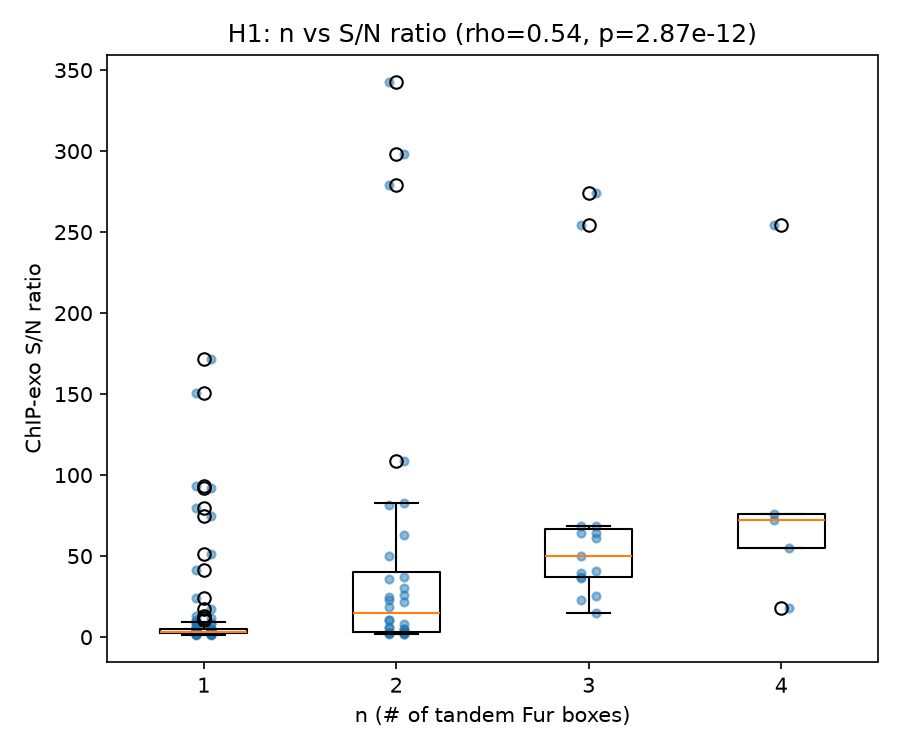

In [1]:
# Figure 1
from IPython.display import Image
Image("../data/module5/fig1_n_vs_sn_ratio.png")

> **Answer**
>
> **Figure 1:** tandem Fur box 개수(n=1–4)별 ChIP-exo S/N ratio 분포를 나타낸 boxplot이다. n이 증가할수록 S/N ratio의 중앙값이 뚜렷하게 함께 증가한다(n=1: 3.4 → n=4: 72.3, Spearman ρ=0.542, p<0.0001).


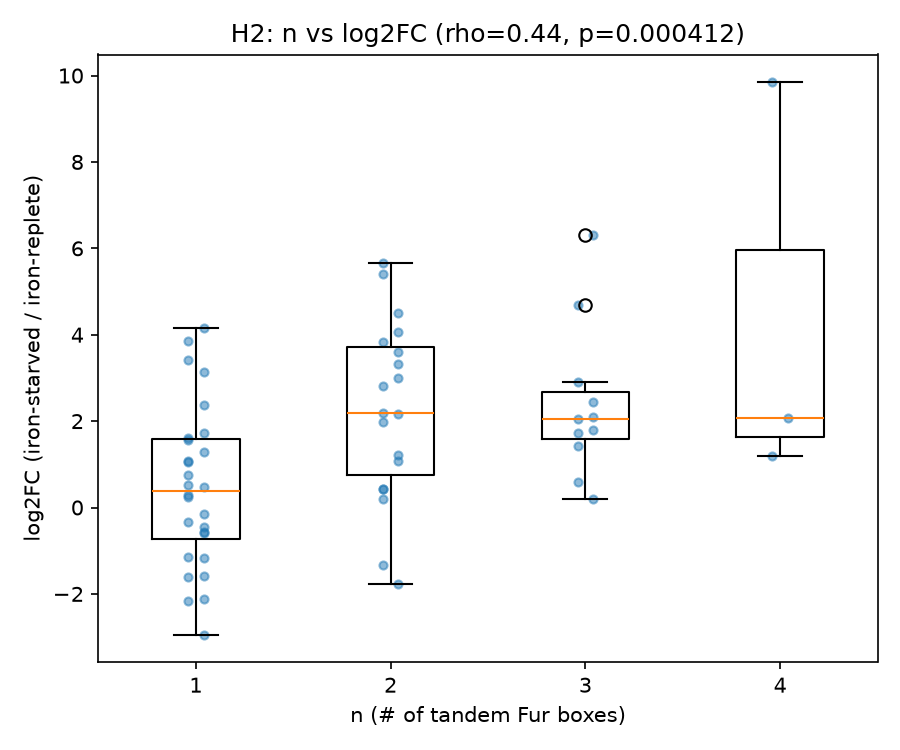

In [2]:
# Figure 2 (add as needed)
from IPython.display import Image
Image("../data/module5/fig2_n_vs_log2fc.png")

> **Answer**
>
> **Figure 2:** tandem Fur box 개수(n=1–4)별 유전자 발현 log2FC(iron-starve/replete) 분포를 나타낸 boxplot이다. n=1에서 n=2로 갈 때 중앙값이 크게 오른 뒤(0.37→2.18) n=3, n=4에서는 거의 변화가 없어(2.04, 2.07) 정체되는 양상을 보인다(ρ=0.438, p=0.0004). 다만 두 Figure의 상관관계 강도 차이는 통계적으로 유의하게 검증된 것은 아니므로, 이는 확정적 결론이 아니라 관찰된 경향으로 해석한다.


> **W6 D3 checkpoint:**
> - [ ] All pipeline steps complete
> - [ ] At least one figure with a written caption
> - [ ] `/log` run


---
## Part 6 — Report
**Target: W6 Days 4–5**

Write your report in the cells below. This is **your own writing** — Claude may be consulted for phrasing, but the scientific content must be yours.


### Question


> **Answer**
>
> tandem Fur box 개수(n=1-4)가 늘수록 ChIP-exo 결합 신호(S/N ratio)는 계속 비례하여 증가하는데(H1), 그 부위가 조절하는 유전자의 실제 전사 억제 강도(log2FC)는 n이 일정 수준을 넘으면 포화(saturate)되어 occupancy만큼 비례해서 강해지지 않는가(H2)?


### Methods
*(tools, parameters, files used — enough to reproduce)*


> **Answer**
>
> SRA DB로부터 accession number SRR1168133 - SRR1168136(iron-replete 2개, iron-starve 2개)인 RNA-seq 데이터들을 다운받고, `bowtie2`로 정렬(`--very-fast -X 1000 -3 3 --no-mixed --no-discordant`, 참조 유전체: NC_000913.2)한다. `samtools`로 좌표 순으로 정렬 후 인덱스를 생성하고, 4개의 데이터에 대해 각각 `makegff.py --flip --separate_strand`으로 linear GFF를 생성한다. `site_to_gene.py`로 Seo et al. 2014 Supplementary Data 1로부터 regulatory region에 존재하는 Fur peak를 Transcription Unit 이름에 기반해 각 gene에 매핑하여 `site_to_gene.tsv`를 생성한다. `tandem_furbox_expression.py`로 각 replicate별로 gene body 구간의 depth를 합산한 뒤, 그 replicate 자신의 total mapped-read count로 CPM 정규화하고, 조건별 두 replicate의 CPM을 평균 내어 log2FC를 계산하여 `tandem_furbox_hypothesis_table.tsv`를 생성한다. 마지막으로 두 가설을 검증하기 위해 `tandem_furbox_hypothesis_test.py`를 통해 H1(n vs S/N ratio), H2(n vs log2FC, gene 단위 집계)에 대해 각각 Spearman + Kruskal-Wallis 통계 검정을 수행 후 `fig1_n_vs_sn_ratio.png`와 `fig2_n_vs_log2fc.png`를 생성한다.

### Results
*(what did you find? reference figures by number)*


> **Answer**
>
> Figure 1에서 tandem Fur box 개수(n)가 증가함에 따라 S/N ratio의 중앙값이 지속적으로 증가했으며(n=1→3.4, n=2→14.7, n=3→50.2, n=4→72.3), 유의한 양의 단조 상관관계가 확인되었다 (Spearman's ρ = 0.542, p < 0.0001, n = 143; Kruskal-Wallis H(3) = 43.6, p < 0.0001). 
>
> Figure 2에서는 log2FC가 n=2 이후 더 이상 증가하지 않는 정체 양상이 관찰되었다(n=1→0.37, n=2→2.18, n=3→2.04, n=4→2.07). n과 log2FC의 상관관계는 여전히 유의했지만 H1보다 상대적으로 약했다 (Spearman's ρ = 0.438, p = 0.0004, n = 61 gene; Kruskal-Wallis H(3) = 12.5, p = 0.0059).
>
> Fur의 결합 강도(S/N ratio)는 n=4까지 계속 증가하는 반면, 전사 억제 강도(RNA-seq log2FC)는 n=2 이후 정체되는 패턴이 관찰되었다. 단, 두 ρ 값 차이 자체를 통계적으로 직접 검정한 건 아니다.


### Interpretation
*(what does this mean biologically? how does it compare to the known FUR regulon?)*


> **Answer**
>
> Fur 전사인자의 전사 억제 기전에 의하면, holo-Fur dimer 하나만으로도 RNAP 또는 시그마 인자가 접근하는 것을 충분히 막을 수 있다. 따라서 이번 미니프로젝트에서 어떤 Transcription unit, 또는 gene의 regulatory region에서 Fur box 개수가 늘어날 수록 결합 신호(S/N ratio)는 계속 늘 수 있지만, 결합에 의한 기능적 결과(전사 억제, iron-replete 대비 iron-starve에서의 log2FC)는 dimer 하나로 충분히 억제된 이후에 더 이상의 한계효용의 증가는 없을 것이라는 해석을 했고, 실제 관찰된 패턴(S/N ratio는 n=4까지 증가, log2FC는 n=2 이후 정체)이 이 해석과 방향과 일치했다.
>
> Escolar et al. 1998 (GATAAT array 결합 특성), Chen et al. 2007 (information theory 기반 Fur binding cluster 규명)에서 tandem 또는 cluster 형태의 Fur box의 존재 자체는 다루고 있지만, 그것이 실제 발현 억제와 어떤 관계를 이루는지는 다루지 않았다. 이 미니프로젝트에서 이 research gap을 채우고자 했다.


### Limitations
*(what would you do differently with more time?)*


> **Answer**
>
>H1/H2에서 사용한 n(tandem Fur box 개수)이 실제 서열 수준의 motif 개수를 얼마나 잘 반영하는지 확인하기 위해, Seo et al. 2014가 명시한 파라미터(MEME width=21bp, FIMO threshold P<0.0001)로 동일한 143개 site에 대해 독립적으로 motif discovery를 재현했다. Fur box 모티프(AWTGATAATCATTCTCAWTCA, E=3.1e-184, 141/143 site에서 검출)로 FIMO를 돌린 뒤, 모티프가 palindromic해서 같은 물리적 위치가 양쪽 가닥에서 중복 검출되는 경우를 5bp 이내 겹침 기준으로 병합하여 site별 hit 개수를 셌다.
>
> 전체 143개 site에서 재현된 hit 개수는 논문의 n과 유의한 양의 상관관계를 보였으나(Spearman ρ=0.456, p=1.0e-08), 정확 일치율은 42.0%(60/143)였다. 특히 regulation mode별로 나누면 불일치가 고르지 않다: H2가 실제로 검증하는 holo-Fur repression(Mode=HR, 47 site, H2에 쓰인 79 site 중 최대 그룹)에서 정확 일치율이 25.5%로 가장 낮았고, mode가 배정되지 않은 site(53.1%)나 holo-Fur activation(HA, N=9로 작음)보다 뚜렷이 낮았다. 즉 n의 불확실성이 무작위로 퍼져 있는 게 아니라, H2가 정면으로 검증하려는 바로 그 HR 부위군에 더 집중돼 있어, H2의 결과(포화 패턴)를 해석할 때 특히 주의가 필요하다.
>
> H2는 gene 단위로 집계한 뒤에 표본 크기가 작았다(N=61, 특히 n=4는 gene 3개뿐이라 median이 불안정할 수 있음). 또한 H1의 ρ(0.542)와 H2의 ρ(0.438)를 비교할 때 두 값의 차이를 Fisher r-to-z 같은 검정으로 통계적으로 확인하지는 않았으므로, "결합 신호보다 전사 억제 효과가 더 약하게 반응한다"는 결론은 관찰된 경향일 뿐 통계적으로 확증되었다고 하기는 어렵다. 또한 site-to-gene 매핑에서 하나의 Fur peak을 TU 내 가장 가까운 대표 gene 하나에만 연결했는데, 실제로는 하나의 결합 부위가 operon 내 여러 유전자를 동시에 조절할 수 있어 이 단순화가 실제 조절 관계의 일부를 놓쳤을 가능성이 있다.
>
> 또한 시간이 더 있었다면, ChIP-exo 데이터만으로는 알 수 없는 부분인 tandem Fur box 하나에 실제로 holo-Fur dimer가 몇 개가 어떤 모양으로 결합하는지 직접 확인하는 실험을 해보고 싶다.

---
Run `/log` one last time, then submit this notebook as your deliverable.


## Git — Commit Your Work

Every session ends with a commit. Run the commands below in your terminal (not in this notebook).

Write your own commit message following the format: `feat(miniproject): <what you did>`.  
If you're unsure what to write, ask Claude Code to suggest one based on what you worked on.

In [9]:
# Run these in the terminal (not here):
# git add notebooks/
# git commit -m "..."   # write your own commit message; use Claude Code to help if needed
# git push
